# 05 — Network clock vs reference clocks

**Two evaluation modes:**
1. **Random 80/20 split** (mode = `random`) — standard internal validation
2. **Cross-cohort** (mode = `cross_cohort`) — train on all datasets except GSE42861, test on GSE42861. Tests whether the clock generalizes across studies.

Both modes produce identical sets of plots so they can be compared side-by-side.

**Reference clocks** (Horvath, Hannum, AltumAge, Skin & Blood, Han) are evaluated using **pyaging's pre-trained coefficients** — no refit. We feed them the *test-set* methylation data and compute R² and MAE against true ages.

**Network clock**: built using PageRank to pick one representative CpG per top-N modules (N ∈ {5, 10, ..., 200, 300}), then fit ElasticNet on training data.

**Module count cap**: 300 — keeps the ensemble cell tractable and avoids overfitting to thousands of features.

In [1]:
import os, warnings, pickle, json
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────
FILTERED_BETAS = "outputs/01_filtered_betas/BetaMatrix_0.35.tsv"
FULL_BETAS     = "inputs/Beta_ALL.tsv"
SAMPLESHEET    = "outputs/01_filtered_betas/Samplesheet.csv"
NETWORK_GEXF   = "outputs/02_network/network_0.70.gexf"
MODULE_CSV     = "outputs/02_network/module_assignments_0.70.csv"

# Two evaluation modes — both will run
EVAL_MODES = ["random"]#, "cross_cohort"]
HOLDOUT_STUDY = "GSE42861"   # used only when mode == 'cross_cohort'

# Network-clock parameters
MAX_MODULES = 1000
MODULE_COUNTS_TO_TEST = [ 10, 20, 30, 40, 50, 60, 70,80,90, 100, 200, 300,400,500]
ENET_ALPHA = 0.5
ENET_N_ALPHAS = 100
ENET_CV_FOLDS = 5
TEST_FRACTION = 0.2  # used only for the 'random' mode
N_ENSEMBLE = 30
SEED = 42

REFERENCE_CLOCKS = ["horvath2013", "hannum", "altumage", "skinandblood", "han"]
CLOCK_LABELS = {
    "horvath2013": "Horvath", "hannum": "Hannum", "altumage": "AltumAge",
    "skinandblood": "Skin & Blood", "han": "Han",
}

DPI = 300
mpl.rcParams.update({
    "font.family": "Arial", "font.size": 12,
    "axes.labelsize": 12, "figure.dpi": DPI, "savefig.dpi": DPI,
    "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def _save(fig, path):
    p = Path(path)
    fig.savefig(str(p), dpi=DPI)
    fig.savefig(str(p.with_suffix(".svg")))
    print(f"  -> {p}")

STUDY_PALETTE = ["#4477AA","#EE6677","#228833","#CCBB44","#66CCEE",
                 "#AA3377","#BBBBBB","#E69F00","#56B4E9","#009E73",
                 "#D55E00","#CC79A7","#0072B2","#F0E442","#882255"]

# ── Saved clocks output dir (used by test_network_clock_3cohorts.ipynb) ──
SAVED_CLOCKS_DIR = Path("outputs/05_clock_ridge/saved_clocks")
SAVED_CLOCKS_DIR.mkdir(parents=True, exist_ok=True)

# ── Cached pyaging reference-clock evaluation ──
# If REF_SUMMARY_CSV already exists, read the per-clock R²/MAE from it instead of
# re-loading BETA_all.tsv and re-running pyaging. Override the path if you save
# the summary under a τ-specific name like outputs/05_clock_0.70/all_modes_summary.csv.
REF_SUMMARY_CSV = Path("outputs/05_clock/all_modes_summary.csv")
FORCE_RECOMPUTE_REF = False    # set True to bypass the CSV cache and recompute

# Random-sampling sweep parameters
N_REPS_SWEEP = 100                # reps per M for each random method
RANDOM_BASE_SEED = 12345          # base seed for the random methods


## 1. Data loaders + helpers (shared across modes)

In [2]:
def load_methylation(beta_path, sheet_path):
    """Load methylation matrix with Sample × CpG layout, plus aligned metadata.
    Returns (df_meth indexed by Sample_ID, meta DataFrame with Age + Study_ID)."""
    print(f"Loading {beta_path} ...")
    df = pd.read_csv(beta_path, sep="\t", low_memory=False)

    cpg_cols = [c for c in df.columns if str(c).startswith("cg")]
    if not cpg_cols:
        fc = df.columns[0]
        if df[fc].astype(str).head(20).str.startswith("cg").sum() > 10:
            df = df.set_index(fc).T.reset_index()
            df.rename(columns={df.columns[0]: "Sample_ID"}, inplace=True)
        cpg_cols = [c for c in df.columns if str(c).startswith("cg")]

    idc = next((c for c in ["Sample_ID", "ID_REF", "ID", "Sample", "geo_accession"]
                if c in df.columns), None)
    df_meth = df[cpg_cols].apply(pd.to_numeric, errors="coerce")
    if idc:
        df_meth.index = df[idc].astype(str)

    meta = pd.read_csv(sheet_path)
    for c in meta.columns:
        if c.lower() == "age":
            meta = meta.rename(columns={c: "Age"})
    meta["Age"] = pd.to_numeric(meta["Age"], errors="coerce")

    mid = next((c for c in ["Sample_ID", "ID_REF", "ID", "Sample", "geo_accession"]
                if c in meta.columns), None)
    if mid:
        meta = meta.set_index(meta[mid].astype(str))
    common = df_meth.index.intersection(meta.index)
    df_meth = df_meth.loc[common]
    meta = meta.loc[common]

    if "Study_ID" not in meta.columns:
        for alt in ["GSE", "Study", "Series", "Dataset"]:
            if alt in meta.columns:
                meta = meta.rename(columns={alt: "Study_ID"})
                break
        if "Study_ID" not in meta.columns:
            meta["Study_ID"] = "unknown"

    print(f"  Loaded: {df_meth.shape[0]} samples × {df_meth.shape[1]:,} CpGs")
    print(f"  Studies: {meta['Study_ID'].value_counts().to_dict()}")
    return df_meth, meta

In [3]:
# Load filtered betas (for the network-clock fit)
df_meth, meta = load_methylation(FILTERED_BETAS, SAMPLESHEET)
ages = meta["Age"].values
study_ids = meta["Study_ID"].values

# Full betas will be loaded LATER (in the evaluation loop) only if the pyaging
# reference-clock cache misses for any mode. This avoids the multi-GB load on
# re-runs where only plotting cells changed.
df_meth_full = None
meta_full    = None

# ── Helper: load cached reference-clock results from the summary CSV ──
# Map from human-readable clock label (CSV "clock" column) back to the internal
# pyaging clock key, so downstream code can keep using the same dict shape.
_LABEL_TO_KEY = {v: k for k, v in CLOCK_LABELS.items()}

def _load_ref_results_from_csv(mode=None, csv_path=REF_SUMMARY_CSV):
    """Return a dict in the same shape as evaluate_reference_clocks_pyaging,
    but populated only with summary metrics (no y_test/pred_test predictions).
    Filters only by the `clock` column — ignores `mode` (the same reference-clock
    values apply across modes, and the column may or may not be present).
    Returns None if the CSV doesn't exist or has no usable rows."""
    if not csv_path.exists():
        print(f"    [ref-cache] CSV not found: {csv_path}")
        return None
    df = pd.read_csv(csv_path)
    if "clock" not in df.columns:
        print(f"    [ref-cache] CSV has no 'clock' column — skipping cache")
        return None
    # Keep only known reference clocks (by label match) — drops Network*, drops noise
    known_labels = set(CLOCK_LABELS.values())
    df = df[df["clock"].astype(str).isin(known_labels)]
    if len(df) == 0:
        print(f"    [ref-cache] No reference-clock rows found in {csv_path}")
        return None
    # If there are duplicates (e.g. one row per mode), keep the first occurrence per clock
    df = df.drop_duplicates(subset=["clock"], keep="first")
    out = {}
    for _, row in df.iterrows():
        label = str(row["clock"])
        key = _LABEL_TO_KEY.get(label, label)
        r2_col = "r2_test" if "r2_test" in df.columns else ("r2" if "r2" in df.columns else None)
        mae_col = "mae_test" if "mae_test" in df.columns else ("mae" if "mae" in df.columns else None)
        if r2_col is None or mae_col is None:
            print(f"    [ref-cache] CSV missing r2/mae columns — skipping cache")
            return None
        entry = {
            "clock_name": label,
            "r2_test":  float(row[r2_col]),
            "mae_test": float(row[mae_col]),
        }
        if "medae_test" in df.columns and pd.notna(row.get("medae_test")):
            entry["medae_test"] = float(row["medae_test"])
        if "n_test" in df.columns and pd.notna(row.get("n_test")):
            entry["n_test_samples"] = int(row["n_test"])
            entry["n_total_test"]    = int(row["n_test"])
        out[key] = entry
    return out


# Network + module assignments
print(f"\nLoading network from {NETWORK_GEXF} ...")
G = nx.read_gexf(NETWORK_GEXF)
module_dict = pd.read_csv(MODULE_CSV).set_index("CpG")["Module"].to_dict()
print(f"  Network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  Modules: {len(set(module_dict.values()))} unique")

# Confirm holdout study exists
if HOLDOUT_STUDY not in set(study_ids):
    print(f"\n⚠  WARNING: holdout study '{HOLDOUT_STUDY}' not found in samplesheet.")
    print(f"   Available studies: {sorted(set(study_ids))}")
    print(f"   Cross-cohort mode will be skipped.")


Loading outputs/01_filtered_betas/BetaMatrix_0.35.tsv ...
  Loaded: 1917 samples × 7,328 CpGs
  Studies: {'GSE87571': 664, 'GSE51032': 424, 'GSE125105': 210, 'GSE42861': 209, 'GSE61496': 150, 'GSE59065': 97, 'GSE87648': 73, 'GSE81961': 25, 'E_MTAB_4931': 24, 'GSE99624': 16, 'GSE87640': 13, 'GSE107737': 12}

Loading network from outputs/02_network/network_0.70.gexf ...
  Network: 7,328 nodes, 272,032 edges
  Modules: 4595 unique


## 2. Score modules by mean |ρ| with age (used to rank modules)

In [4]:
ages_s = pd.Series(ages, index=df_meth.index)
available_cpgs = [c for c in module_dict if c in df_meth.columns]
rho_age = df_meth[available_cpgs].corrwith(ages_s, method="spearman").abs().dropna()

mod_cpgs = defaultdict(list)
for cpg, m in module_dict.items():
    if cpg in rho_age.index:
        mod_cpgs[m].append(cpg)

rows = []
for m, cpgs in mod_cpgs.items():
    rhos = [rho_age[c] for c in cpgs if c in rho_age.index]
    if not rhos: continue
    rows.append({"Module": m, "n_cpgs": len(cpgs),
                 "mean_abs_rho": np.mean(rhos),
                 "median_abs_rho": np.median(rhos),
                 "max_abs_rho": np.max(rhos), "cpgs": cpgs})
df_scores = pd.DataFrame(rows).sort_values("mean_abs_rho", ascending=False).reset_index(drop=True)
df_scores["rank"] = range(1, len(df_scores) + 1)
df_scores["cpgs"] = df_scores["Module"].map(lambda m: mod_cpgs.get(m, []))

print(f"  {len(df_scores)} modules scored")
print("Top 10 by mean |ρ|:")
print(df_scores.head(10)[["Module", "n_cpgs", "mean_abs_rho", "max_abs_rho"]].to_string(index=False))

  4595 modules scored
Top 10 by mean |ρ|:
 Module  n_cpgs  mean_abs_rho  max_abs_rho
   1937       1      0.673741     0.673741
   2910       1      0.671261     0.671261
   3982       1      0.645269     0.645269
   2106       1      0.643239     0.643239
     46       4      0.641545     0.717814
      5      20      0.639666     0.826646
   1214       1      0.639019     0.639019
   4336       1      0.636991     0.636991
   2500       1      0.631315     0.631315
   3139       1      0.630996     0.630996


## 3. ElasticNet fit + split helpers

In [5]:
def make_split(df_meth, ages, study_ids, mode, seed=42):
    """Return (i_tr, i_te) — integer indices into df_meth.
    mode='random'         : random 80/20 split (TEST_FRACTION).
    mode='cross_cohort'   : test = HOLDOUT_STUDY, train = all other studies.
    """
    n = len(ages)
    idx = np.arange(n)
    if mode == "random":
        i_tr, i_te = train_test_split(idx, test_size=TEST_FRACTION, random_state=seed)
    elif mode == "cross_cohort":
        sids = np.array(study_ids)
        i_te = idx[sids == HOLDOUT_STUDY]
        i_tr = idx[sids != HOLDOUT_STUDY]
        if len(i_te) == 0:
            raise ValueError(f"No samples found for holdout study '{HOLDOUT_STUDY}'")
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return i_tr, i_te


def fit_enet_with_split(df_meth, ages, cpg_list, i_tr, i_te, study_ids=None,
                        alpha=0.5, n_alphas=100, cv_folds=5, seed=42):
    """Fit ElasticNetCV on i_tr, evaluate on i_te. Returns dict of metrics + preds.
    Keeps the same return shape as the original fit_enet so all downstream
    plotting code works identically."""
    avail = [c for c in cpg_list if c in df_meth.columns]
    if len(avail) < 2:
        return None
    X = df_meth[avail].fillna(df_meth[avail].mean()).values
    y = np.array(ages, dtype=float)

    X_tr, y_tr = X[i_tr], y[i_tr]
    X_te, y_te = X[i_te], y[i_te]
    sids = np.array(study_ids) if study_ids is not None else None
    s_tr = sids[i_tr] if sids is not None else None
    s_te = sids[i_te] if sids is not None else None

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    m = ElasticNetCV(l1_ratio=alpha, n_alphas=n_alphas, cv=cv_folds,
                      random_state=seed, max_iter=10000)
    m.fit(X_tr_s, y_tr)
    p_tr = m.predict(X_tr_s); p_te = m.predict(X_te_s)
    return {
        "model": m, "scaler": sc, "cpgs_used": avail,
        "n_cpgs_input": len(avail), "n_cpgs_nonzero": int(np.sum(m.coef_ != 0)),
        "r2_train": r2_score(y_tr, p_tr), "r2_test": r2_score(y_te, p_te),
        "mae_train": mean_absolute_error(y_tr, p_tr),
        "mae_test": mean_absolute_error(y_te, p_te),
        "medae_test": median_absolute_error(y_te, p_te),
        "y_train": y_tr, "y_test": y_te,
        "pred_train": p_tr, "pred_test": p_te,
        "studies_train": s_tr, "studies_test": s_te,
    }


def pagerank_reps(G, df_scores, n_modules):
    """Pick the highest-PageRank CpG from each of top-N modules."""
    reps = []
    for _, row in df_scores.head(n_modules).iterrows():
        sub_nodes = [c for c in row["cpgs"] if G.has_node(c)] \
                    if isinstance(row.get("cpgs"), list) else []
        if not sub_nodes: continue
        sub = G.subgraph(sub_nodes)
        try:
            pr = nx.pagerank(sub, weight="weight")
        except Exception:
            pr = {n: 1.0 for n in sub_nodes}
        reps.append(max(pr, key=pr.get))
    return reps


def fit_ols_with_split(df_meth, ages, cpg_list, i_tr, i_te, study_ids=None,
                          seed=42, max_p_n_ratio=0.99):
    """Plain OLS variant of fit_enet_with_split. Same return shape so downstream
    code works unchanged.

    No penalty, no CV, no alpha grid — a single closed-form least-squares solve.

    Refuses to fit when p >= n_train * max_p_n_ratio (OLS becomes degenerate at
    p ≥ n). Caller should cap M upstream; this is just a defensive guard.
    """
    avail = [c for c in cpg_list if c in df_meth.columns]
    if len(avail) < 2:
        return None
    X = df_meth[avail].fillna(df_meth[avail].mean()).values
    y = np.array(ages, dtype=float)

    X_tr, y_tr = X[i_tr], y[i_tr]
    X_te, y_te = X[i_te], y[i_te]

    # OLS guard: p must be safely below n
    n_tr = len(i_tr)
    p = X_tr.shape[1]
    if p >= n_tr * max_p_n_ratio:
        raise ValueError(
            f"OLS refused: p={p} >= {max_p_n_ratio}*n_train={n_tr*max_p_n_ratio:.0f}. "
            f"Cap M further or switch to a regularized fit at this size."
        )

    sids = np.array(study_ids) if study_ids is not None else None
    s_tr = sids[i_tr] if sids is not None else None
    s_te = sids[i_te] if sids is not None else None

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    m = LinearRegression()
    m.fit(X_tr_s, y_tr)
    p_tr = m.predict(X_tr_s); p_te = m.predict(X_te_s)
    return {
        "model": m, "scaler": sc, "cpgs_used": avail,
        "n_cpgs_input": len(avail),
        "n_cpgs_nonzero": int(np.sum(m.coef_ != 0)),   # OLS has all coefs ≠ 0 in general
        "r2_train": r2_score(y_tr, p_tr), "r2_test": r2_score(y_te, p_te),
        "mae_train": mean_absolute_error(y_tr, p_tr),
        "mae_test": mean_absolute_error(y_te, p_te),
        "medae_test": median_absolute_error(y_te, p_te),
        "y_train": y_tr, "y_test": y_te,
        "pred_train": p_tr, "pred_test": p_te,
        "studies_train": s_tr, "studies_test": s_te,
    }


def fit_ridge_with_split(df_meth, ages, cpg_list, i_tr, i_te, study_ids=None,
                            alphas=None, cv_folds=5, seed=42):
    """Ridge (L2) variant of fit_ols_with_split. Same return shape so downstream
    code works unchanged.

    Why ridge here: ~1500 training samples + correlated methylation features
    (CpGs within the same module are correlated by construction) make plain OLS
    high-variance even when p < n. Ridge shrinks coefficients toward zero,
    trading a small bias for a big variance reduction, and spreads signal
    across correlated CpGs rather than zeroing them out (unlike Lasso).

    Uses RidgeCV with a log-spaced alpha grid; the L2 strength is picked by
    k-fold CV on the training fold — no manual tuning. Unlike OLS, ridge is
    well-defined for p >= n, so the OLS_MAX_M cap is not strictly needed.
    """
    avail = [c for c in cpg_list if c in df_meth.columns]
    if len(avail) < 2:
        return None
    X = df_meth[avail].fillna(df_meth[avail].mean()).values
    y = np.array(ages, dtype=float)

    X_tr, y_tr = X[i_tr], y[i_tr]
    X_te, y_te = X[i_te], y[i_te]
    sids = np.array(study_ids) if study_ids is not None else None
    s_tr = sids[i_tr] if sids is not None else None
    s_te = sids[i_te] if sids is not None else None

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    if alphas is None:
        alphas = np.logspace(-3, 3, 25)
    m = RidgeCV(alphas=alphas, cv=cv_folds)
    m.fit(X_tr_s, y_tr)
    p_tr = m.predict(X_tr_s); p_te = m.predict(X_te_s)
    return {
        "model": m, "scaler": sc, "cpgs_used": avail,
        "n_cpgs_input": len(avail),
        "n_cpgs_nonzero": int(np.sum(m.coef_ != 0)),
        "alpha": float(m.alpha_),
        "r2_train": r2_score(y_tr, p_tr), "r2_test": r2_score(y_te, p_te),
        "mae_train": mean_absolute_error(y_tr, p_tr),
        "mae_test": mean_absolute_error(y_te, p_te),
        "medae_test": median_absolute_error(y_te, p_te),
        "y_train": y_tr, "y_test": y_te,
        "pred_train": p_tr, "pred_test": p_te,
        "studies_train": s_tr, "studies_test": s_te,
    }


## 4. Reference clocks via pyaging — predict on the test set with pre-trained coefficients

Uses `pya.pred.predict_age` on the test-set methylation data. Returns a dict of (clock_name → DataFrame with predicted ages).

Key difference from the previous notebook: **we no longer refit ElasticNet** for reference clocks. We use their published coefficients directly (which is what they're meant for — they're pre-trained age predictors).

In [6]:
# Try to import pyaging — if missing, ref-clock evaluation gets skipped
try:
    import pyaging as pya
    import anndata
    PYAGING_AVAILABLE = True
except ImportError:
    PYAGING_AVAILABLE = False
    print("⚠  pyaging not installed — pip install pyaging")
    print("   Reference clock evaluation will be skipped.")


def evaluate_reference_clocks_pyaging(df_meth_full, ages, i_te, study_ids,
                                        clocks=REFERENCE_CLOCKS):
    """Run each reference clock on the FULL beta matrix using pyaging's
    pre-trained coefficients, then evaluate on test indices.

    Uses the AnnData-based API documented on pyaging's GitHub:
        adata = pya.preprocess.df_to_adata(df, imputer_strategy='mean')
        pya.pred.predict_age(adata, clocks)
        # predictions appear as columns in adata.obs

    Returns dict {clock_name: dict of metrics}.
    """
    if not PYAGING_AVAILABLE:
        return {}

    out = {}
    # pyaging expects a Sample × CpG DataFrame (samples as rows)
    df_in = df_meth_full.copy()

    # Build AnnData once and run all clocks on it (faster than per-clock)
    print("  Building AnnData ...", end=" ", flush=True)
    adata = pya.preprocess.df_to_adata(df_in, imputer_strategy="mean", verbose=False)
    print(f"shape {adata.shape}")

    print(f"  Running {len(clocks)} clocks via pyaging ...", flush=True)
    pya.pred.predict_age(adata, clocks, verbose=False)

    for cn in clocks:
        col = cn if cn in adata.obs.columns else None
        if col is None:
            # try case-insensitive match
            for c in adata.obs.columns:
                if c.lower() == cn.lower():
                    col = c; break
        if col is None:
            print(f"  {CLOCK_LABELS[cn]:14s}: FAILED (no '{cn}' column in adata.obs)")
            continue

        pred = adata.obs[col].reindex(df_meth_full.index).values
        y_te = ages[i_te]
        p_te = pred[i_te]
        mask = ~pd.isna(p_te) & ~pd.isna(y_te)
        if mask.sum() < 2:
            print(f"  {CLOCK_LABELS[cn]:14s}: FAILED (no valid predictions)")
            continue
        y_te = y_te[mask].astype(float)
        p_te = p_te[mask].astype(float)
        s_te = (np.array(study_ids)[i_te])[mask]

        r2 = r2_score(y_te, p_te)
        mae = mean_absolute_error(y_te, p_te)
        medae = median_absolute_error(y_te, p_te)
        out[cn] = {
            "clock_name": CLOCK_LABELS[cn],
            "r2_test": r2, "mae_test": mae, "medae_test": medae,
            "y_test": y_te, "pred_test": p_te,
            "studies_test": s_te,
            "n_test_samples": int(mask.sum()),
            "n_total_test": len(i_te),
        }
        print(f"  {CLOCK_LABELS[cn]:14s}: R²={r2:.3f}, MAE={mae:.2f}y (n={mask.sum()}/{len(i_te)})")
    return out


## 5. Run both evaluation modes

For each mode (`random`, `cross_cohort`):
- Build train/test split
- Sweep network clock over module counts {5, 10, …, 200, 300}
- Pick best by test-R²
- Evaluate reference clocks on the same test set using pyaging
- Save artifacts to `outputs/05_clock/{mode}/`

In [7]:
# Container for per-mode results
all_mode_results = {}

# Cap M as a sanity bound. With ridge the p < n constraint no longer applies
# (ridge is well-defined for p >= n), but we keep the cap as a guard against
# pathological cases. Random fold has ~(1-TEST_FRACTION)*N ≈ 0.8 * 1917 ≈ 1530.
OLS_MAX_M = 1500

for mode in EVAL_MODES:
    print(f"\n{'='*70}")
    print(f"  EVALUATION MODE: {mode}")
    print(f"{'='*70}")

    out_dir = Path(f"outputs/05_clock/{mode}")
    out_dir.mkdir(parents=True, exist_ok=True)

    # ── Split ───────────────────────────────────────────────────
    if mode == "cross_cohort" and HOLDOUT_STUDY not in set(study_ids):
        print(f"  Skipping — no '{HOLDOUT_STUDY}' samples")
        continue
    try:
        i_tr, i_te = make_split(df_meth, ages, study_ids, mode, seed=SEED)
    except Exception as e:
        print(f"  Split failed: {e}"); continue

    print(f"  Train: n={len(i_tr)}  |  Test: n={len(i_te)}")
    if mode == "cross_cohort":
        print(f"  Holdout study: {HOLDOUT_STUDY}")
    train_studies = sorted(set(np.array(study_ids)[i_tr]))
    test_studies = sorted(set(np.array(study_ids)[i_te]))
    print(f"  Train studies: {train_studies}")
    print(f"  Test studies:  {test_studies}")

    # NOTE: Method 1 (top-modules + PageRank) is intentionally not run here —
    # only the two random methods below. Downstream cells expect this and skip
    # any references to top-modules.

    # Module counts to test for the random methods (already filtered to <= OLS_MAX_M)
    test_counts = sorted(set(n for n in MODULE_COUNTS_TO_TEST if n <= OLS_MAX_M))



  EVALUATION MODE: random
  Train: n=1533  |  Test: n=384
  Train studies: ['E_MTAB_4931', 'GSE107737', 'GSE125105', 'GSE42861', 'GSE51032', 'GSE59065', 'GSE61496', 'GSE81961', 'GSE87571', 'GSE87640', 'GSE87648', 'GSE99624']
  Test studies:  ['E_MTAB_4931', 'GSE107737', 'GSE125105', 'GSE42861', 'GSE51032', 'GSE59065', 'GSE61496', 'GSE81961', 'GSE87571', 'GSE87640', 'GSE87648', 'GSE99624']


In [8]:
    # ── METHOD 2: Random-from-network — for each M, do N_REPS random picks ─────
    print(f"\n  Method 2: Random-from-network — {N_REPS_SWEEP} reps per M")
    all_filtered_cpgs = list(df_meth.columns)
    rand_net_rows = []
    rand_net_best_by_M = {}

    for n_cpgs in test_counts:
        if n_cpgs > len(all_filtered_cpgs): continue
        best_at_M = None
        best_r2_at_M = -np.inf
        r2_list, mae_list = [], []
        for rep in range(N_REPS_SWEEP):
            rng = np.random.RandomState(RANDOM_BASE_SEED + n_cpgs * 1000 + rep)
            reps_cpgs = list(rng.choice(all_filtered_cpgs, size=n_cpgs, replace=False))
            try:
                res = fit_ridge_with_split(df_meth, ages, reps_cpgs, i_tr, i_te,
                                            study_ids=study_ids,
                                            seed=RANDOM_BASE_SEED + rep)
            except ValueError as e:
                # OLS refused (p too close to n) — skip rep, log once
                if rep == 0:
                    print(f"    n={n_cpgs:3d}  fit refused at this M: {e}")
                continue
            if res is None: continue
            r2_list.append(res["r2_test"]); mae_list.append(res["mae_test"])
            rand_net_rows.append({"method": "random_network", "n_modules": n_cpgs,
                                    "rep": rep, "r2_test": res["r2_test"],
                                    "mae_test": res["mae_test"]})
            if res["r2_test"] > best_r2_at_M:
                best_r2_at_M = res["r2_test"]
                best_at_M = {
                    "cpgs":      res["cpgs_used"],
                    "coefs":     res["model"].coef_.copy(),
                    "intercept": float(res["model"].intercept_),
                    "scaler_mean":  res["scaler"].mean_.copy(),
                    "scaler_scale": res["scaler"].scale_.copy(),
                    "r2_test":   res["r2_test"],
                    "mae_test":  res["mae_test"],
                    "n_cpgs_input":   res["n_cpgs_input"],
                    "n_cpgs_nonzero": res["n_cpgs_nonzero"],
                    "rep":       rep,
                }
        if best_at_M is not None:
            rand_net_best_by_M[n_cpgs] = best_at_M
        if r2_list:
            print(f"    n={n_cpgs:3d}  R² mean={np.mean(r2_list):.3f}±{np.std(r2_list):.3f}  "
                  f"best={best_r2_at_M:.3f}  MAE mean={np.mean(mae_list):.2f}")

    # Save random-network best clocks
    save_path = SAVED_CLOCKS_DIR / f"best_clocks_random_network_{mode}.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(rand_net_best_by_M, f)
    print(f"  Saved random-network clocks → {save_path}")


    # ── METHOD 3: Random-one-per-cluster ─────
    print(f"\n  Method 3: Random-one-per-cluster — {N_REPS_SWEEP} reps per M")
    # Build module -> CpG list dict (all modules including small ones)
    all_module_cpgs = defaultdict(list)
    for cpg, m in module_dict.items():
        if cpg in df_meth.columns:
            all_module_cpgs[m].append(cpg)
    all_module_ids = list(all_module_cpgs.keys())
    n_total_modules = len(all_module_ids)
    print(f"    Total modules available: {n_total_modules}  "
          f"(max M for this method)")

    rand_clust_rows = []
    rand_clust_best_by_M = {}

    for n_mods in test_counts:
        if n_mods > n_total_modules:
            print(f"    n={n_mods:3d}  SKIPPED — only {n_total_modules} modules available")
            continue
        best_at_M = None
        best_r2_at_M = -np.inf
        r2_list, mae_list = [], []
        for rep in range(N_REPS_SWEEP):
            rng = np.random.RandomState(RANDOM_BASE_SEED + n_mods * 7000 + rep)
            picked_modules = rng.choice(all_module_ids, size=n_mods, replace=False)
            reps_cpgs = []
            for mid in picked_modules:
                cpgs_in_mod = all_module_cpgs[mid]
                reps_cpgs.append(rng.choice(cpgs_in_mod))
            try:
                res = fit_ridge_with_split(df_meth, ages, reps_cpgs, i_tr, i_te,
                                            study_ids=study_ids,
                                            seed=RANDOM_BASE_SEED + rep + 50000)
            except ValueError as e:
                if rep == 0:
                    print(f"    n={n_mods:3d}  fit refused at this M: {e}")
                continue
            if res is None: continue
            r2_list.append(res["r2_test"]); mae_list.append(res["mae_test"])
            rand_clust_rows.append({"method": "random_per_cluster", "n_modules": n_mods,
                                      "rep": rep, "r2_test": res["r2_test"],
                                      "mae_test": res["mae_test"]})
            if res["r2_test"] > best_r2_at_M:
                best_r2_at_M = res["r2_test"]
                best_at_M = {
                    "cpgs":      res["cpgs_used"],
                    "coefs":     res["model"].coef_.copy(),
                    "intercept": float(res["model"].intercept_),
                    "scaler_mean":  res["scaler"].mean_.copy(),
                    "scaler_scale": res["scaler"].scale_.copy(),
                    "r2_test":   res["r2_test"],
                    "mae_test":  res["mae_test"],
                    "n_cpgs_input":   res["n_cpgs_input"],
                    "n_cpgs_nonzero": res["n_cpgs_nonzero"],
                    "rep":       rep,
                }
        if best_at_M is not None:
            rand_clust_best_by_M[n_mods] = best_at_M
        if r2_list:
            print(f"    n={n_mods:3d}  R² mean={np.mean(r2_list):.3f}±{np.std(r2_list):.3f}  "
                  f"best={best_r2_at_M:.3f}  MAE mean={np.mean(mae_list):.2f}")

    save_path = SAVED_CLOCKS_DIR / f"best_clocks_random_per_cluster_{mode}.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(rand_clust_best_by_M, f)
    print(f"  Saved random-per-cluster clocks → {save_path}")

    # Save the full random sweep data
    df_rand_net   = pd.DataFrame(rand_net_rows)
    df_rand_clust = pd.DataFrame(rand_clust_rows)
    df_rand_all = pd.concat([df_rand_net, df_rand_clust], ignore_index=True)
    df_rand_all.to_csv(out_dir / "random_sweep_results.csv", index=False)
    print(f"  Saved full random-sweep data → {out_dir / 'random_sweep_results.csv'}")


    # ── Reference clocks via pyaging (with CSV cache) ────────────
    ref_results = None
    if not FORCE_RECOMPUTE_REF:
        ref_results = _load_ref_results_from_csv(mode)
        if ref_results is not None:
            print(f"\n  Reference clocks: loaded from {REF_SUMMARY_CSV}")
            for cn, r in ref_results.items():
                print(f"    {r['clock_name']:14s}: R²={r['r2_test']:.3f}, "
                      f"MAE={r['mae_test']:.2f}y")
    if ref_results is None:
        # Cache miss → need FULL_BETAS for pyaging. Lazy-load once across all modes.
        if df_meth_full is None:
            print(f"\n  Loading FULL_BETAS for pyaging (no cache for mode={mode})...")
            df_meth_full, meta_full = load_methylation(FULL_BETAS, SAMPLESHEET)
            df_meth_full = df_meth_full.loc[df_meth.index]
            meta_full    = meta_full.loc[df_meth.index]
            ages_full    = meta_full["Age"].values
            study_full   = meta_full["Study_ID"].values
            assert np.allclose(ages, ages_full), "Age vectors disagree between filtered and full"
            assert all(study_ids == study_full), "Study IDs disagree between filtered and full"

        print(f"\n  Reference clocks via pyaging:")
        ref_results = evaluate_reference_clocks_pyaging(
            df_meth_full, ages, i_te, study_ids, REFERENCE_CLOCKS
        )
        # The summary CSV gets (re)written by the final summary cell — no need to
        # write it here. ref_results stays in memory for the rest of the notebook.


    all_mode_results[mode] = {
        "out_dir": out_dir,
        "i_tr": i_tr, "i_te": i_te,
        "df_rand_net": df_rand_net,
        "df_rand_clust": df_rand_clust,
        "rand_net_best_by_M":   rand_net_best_by_M,
        "rand_clust_best_by_M": rand_clust_best_by_M,
        "ref_results": ref_results,
    }



  Method 2: Random-from-network — 100 reps per M
    n= 10  R² mean=0.408±0.075  best=0.613  MAE mean=9.83
    n= 20  R² mean=0.513±0.066  best=0.640  MAE mean=8.79
    n= 30  R² mean=0.572±0.056  best=0.696  MAE mean=8.22
    n= 40  R² mean=0.612±0.043  best=0.699  MAE mean=7.74
    n= 50  R² mean=0.633±0.044  best=0.724  MAE mean=7.53
    n= 60  R² mean=0.654±0.033  best=0.719  MAE mean=7.28
    n= 70  R² mean=0.674±0.032  best=0.734  MAE mean=7.04
    n= 80  R² mean=0.687±0.031  best=0.750  MAE mean=6.86
    n= 90  R² mean=0.696±0.026  best=0.745  MAE mean=6.72
    n=100  R² mean=0.709±0.020  best=0.770  MAE mean=6.57
    n=200  R² mean=0.749±0.015  best=0.778  MAE mean=5.97
    n=300  R² mean=0.768±0.010  best=0.800  MAE mean=5.66
    n=400  R² mean=0.780±0.010  best=0.806  MAE mean=5.44
    n=500  R² mean=0.784±0.009  best=0.805  MAE mean=5.34
  Saved random-network clocks → outputs/05_clock_ridge/saved_clocks/best_clocks_random_network_random.pkl

  Method 3: Random-one-per-clus

## 6. Module-sweep plot (per mode)

R² and MAE vs number of modules, with reference clocks as horizontal lines.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_clock/random/module_sweep_with_baselines.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


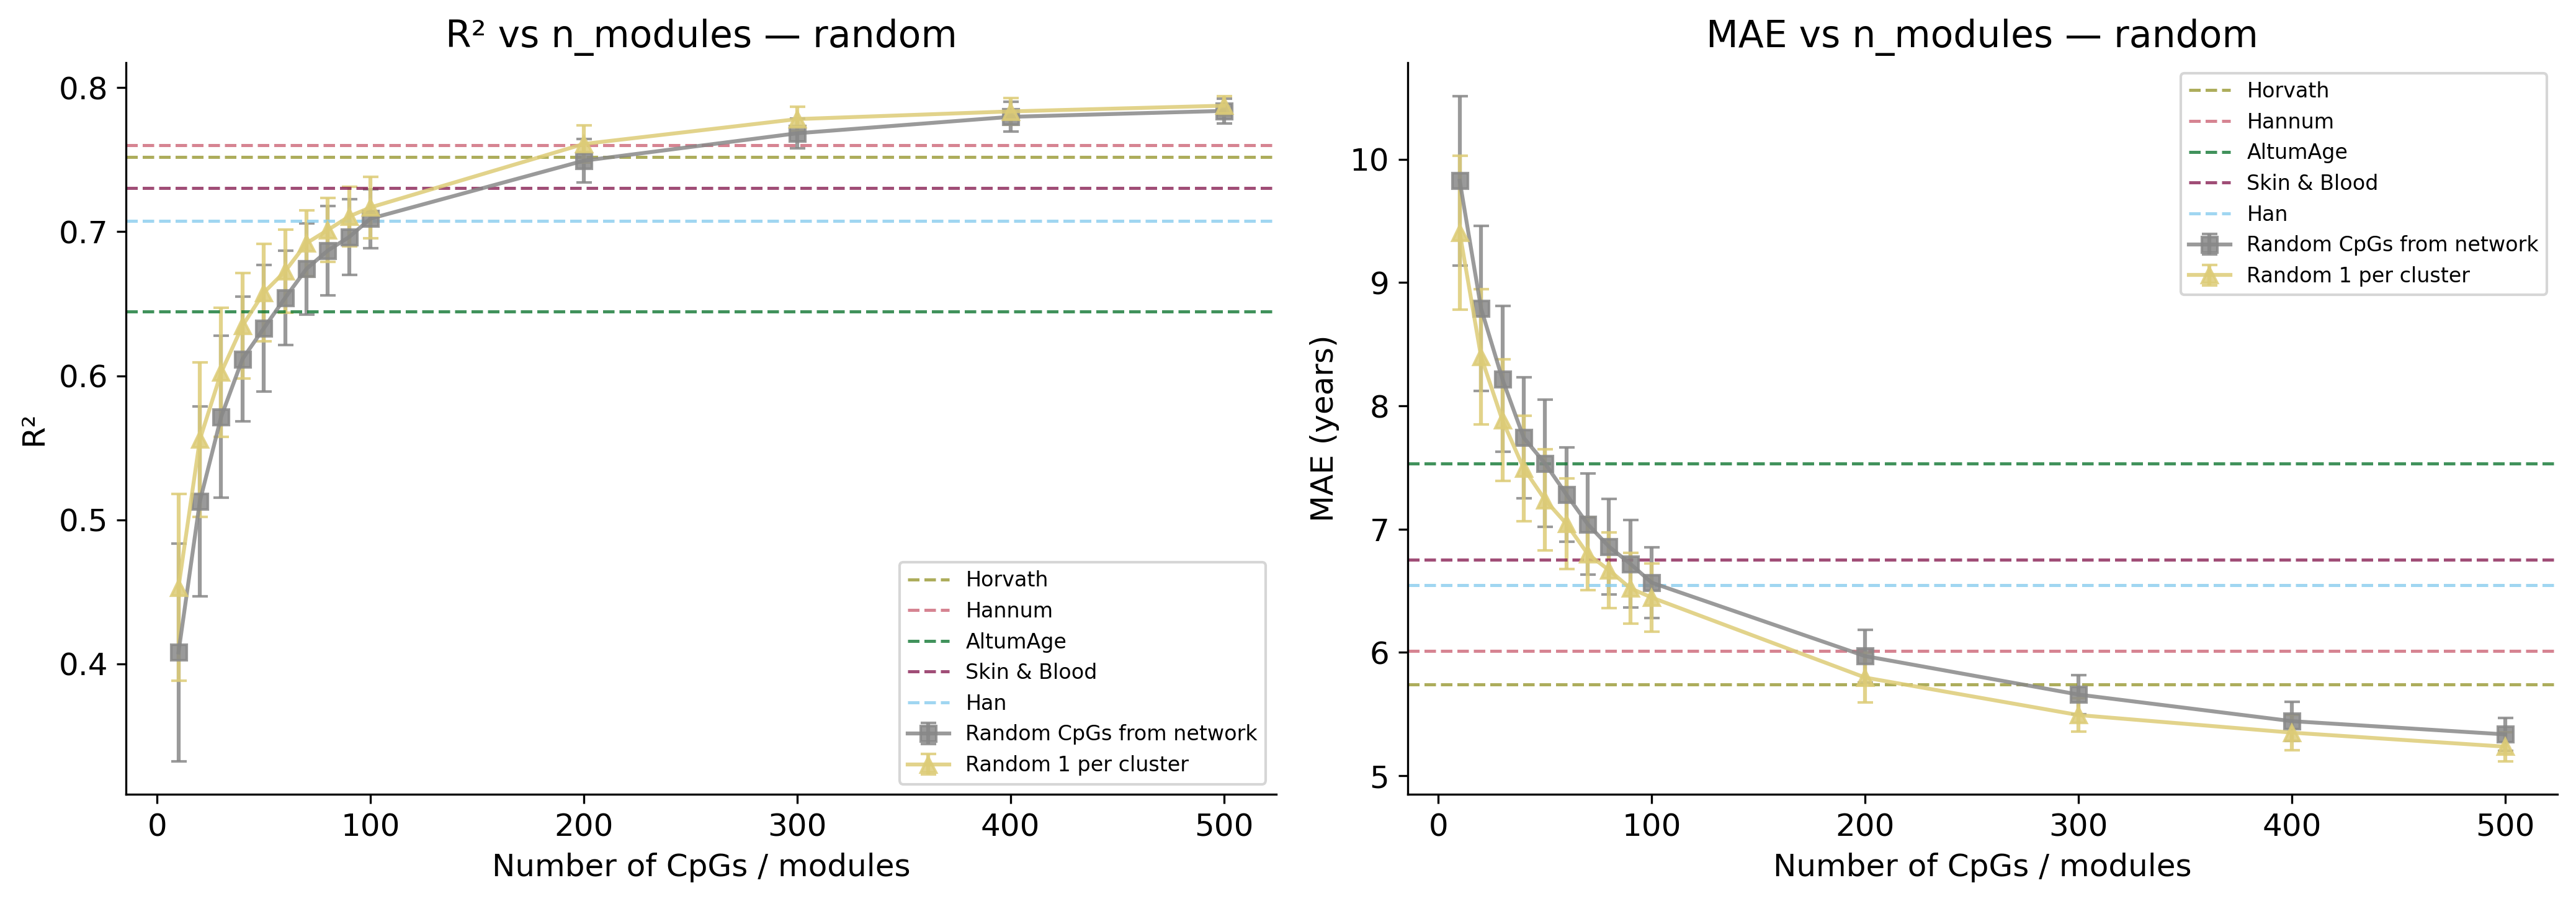

In [9]:
REF_COLOR_MAP = {"horvath2013":"#999933", "hannum":"#CC6677",
                 "altumage":"#117733", "skinandblood":"#882255", "han":"#88CCEE"}

# Method colors — distinguishable, ordered (top-modules = solid primary)
METHOD_COLOR = {
    "top_modules":         "#332288",   # purple — the official network clock
    "random_network":      "#888888",   # grey — completely random
    "random_per_cluster":  "#DDCC77",   # yellow — 1 per cluster
}

for mode, res in all_mode_results.items():
    out_dir = res["out_dir"]
    df_rand_net = res["df_rand_net"]
    df_rand_clust = res["df_rand_clust"]
    ref_results = res["ref_results"]
    title_suffix = f" — {mode.replace('_', ' ')}"

    # Aggregate random methods per M: mean ± std
    def agg(df, key="r2_test"):
        if len(df) == 0:
            return pd.DataFrame(columns=["n_modules", "mean", "std"])
        return df.groupby("n_modules")[key].agg(["mean", "std"]).reset_index()

    rand_net_r2  = agg(df_rand_net,  "r2_test")
    rand_clust_r2 = agg(df_rand_clust, "r2_test")
    rand_net_mae  = agg(df_rand_net,  "mae_test")
    rand_clust_mae = agg(df_rand_clust, "mae_test")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── PANEL 1: R² vs n_modules ──
    ax = axes[0]
    ax.errorbar(rand_net_r2["n_modules"], rand_net_r2["mean"],
                 yerr=rand_net_r2["std"], fmt="s-",
                 color=METHOD_COLOR["random_network"], lw=1.5, markersize=6,
                 alpha=0.85, capsize=3, label="Random CpGs from network")
    ax.errorbar(rand_clust_r2["n_modules"], rand_clust_r2["mean"],
                 yerr=rand_clust_r2["std"], fmt="^-",
                 color=METHOD_COLOR["random_per_cluster"], lw=1.5, markersize=6,
                 alpha=0.85, capsize=3, label="Random 1 per cluster")
    for cn, r in ref_results.items():
        ax.axhline(r["r2_test"], ls="--", lw=1.2, alpha=0.8,
                    color=REF_COLOR_MAP.get(cn, "#666"),
                    label=r["clock_name"])
    ax.set_xlabel("Number of CpGs / modules")
    ax.set_ylabel("R²")
    ax.set_title(f"R² vs n_modules{title_suffix}")
    ax.legend(fontsize=8, loc="lower right")
    sns.despine(ax=ax)

    # ── PANEL 2: MAE vs n_modules ──
    ax = axes[1]
    ax.errorbar(rand_net_mae["n_modules"], rand_net_mae["mean"],
                 yerr=rand_net_mae["std"], fmt="s-",
                 color=METHOD_COLOR["random_network"], lw=1.5, markersize=6,
                 alpha=0.85, capsize=3, label="Random CpGs from network")
    ax.errorbar(rand_clust_mae["n_modules"], rand_clust_mae["mean"],
                 yerr=rand_clust_mae["std"], fmt="^-",
                 color=METHOD_COLOR["random_per_cluster"], lw=1.5, markersize=6,
                 alpha=0.85, capsize=3, label="Random 1 per cluster")
    for cn, r in ref_results.items():
        ax.axhline(r["mae_test"], ls="--", lw=1.2, alpha=0.8,
                    color=REF_COLOR_MAP.get(cn, "#666"),
                    label=r["clock_name"])
    ax.set_xlabel("Number of CpGs / modules")
    ax.set_ylabel("MAE (years)")
    ax.set_title(f"MAE vs n_modules{title_suffix}")
    ax.legend(fontsize=8, loc="upper right")
    sns.despine(ax=ax)

    fig.tight_layout()
    _save(fig, out_dir / "module_sweep_with_baselines.png")
    plt.show()


## 7. Predicted-vs-actual scatter for the best network clock (per mode)

In [10]:
# (Top-modules best-clock scatter is intentionally omitted — only the two
# random methods are evaluated. See the M=100 scatter below for those.)
print("Top-modules best-clock scatter skipped (method disabled).")


Top-modules best-clock scatter skipped (method disabled).


## Predicted-vs-actual for random-method clocks at M=100

Re-applies the saved random-from-network and random-one-per-cluster clocks at M=100 to the same train/test split used to fit them, then plots predicted vs chronological age (Train | Test panels per method).


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_clock/random/scatter_rand_net_M100.csv


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_clock/random/scatter_rand_net_M100.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

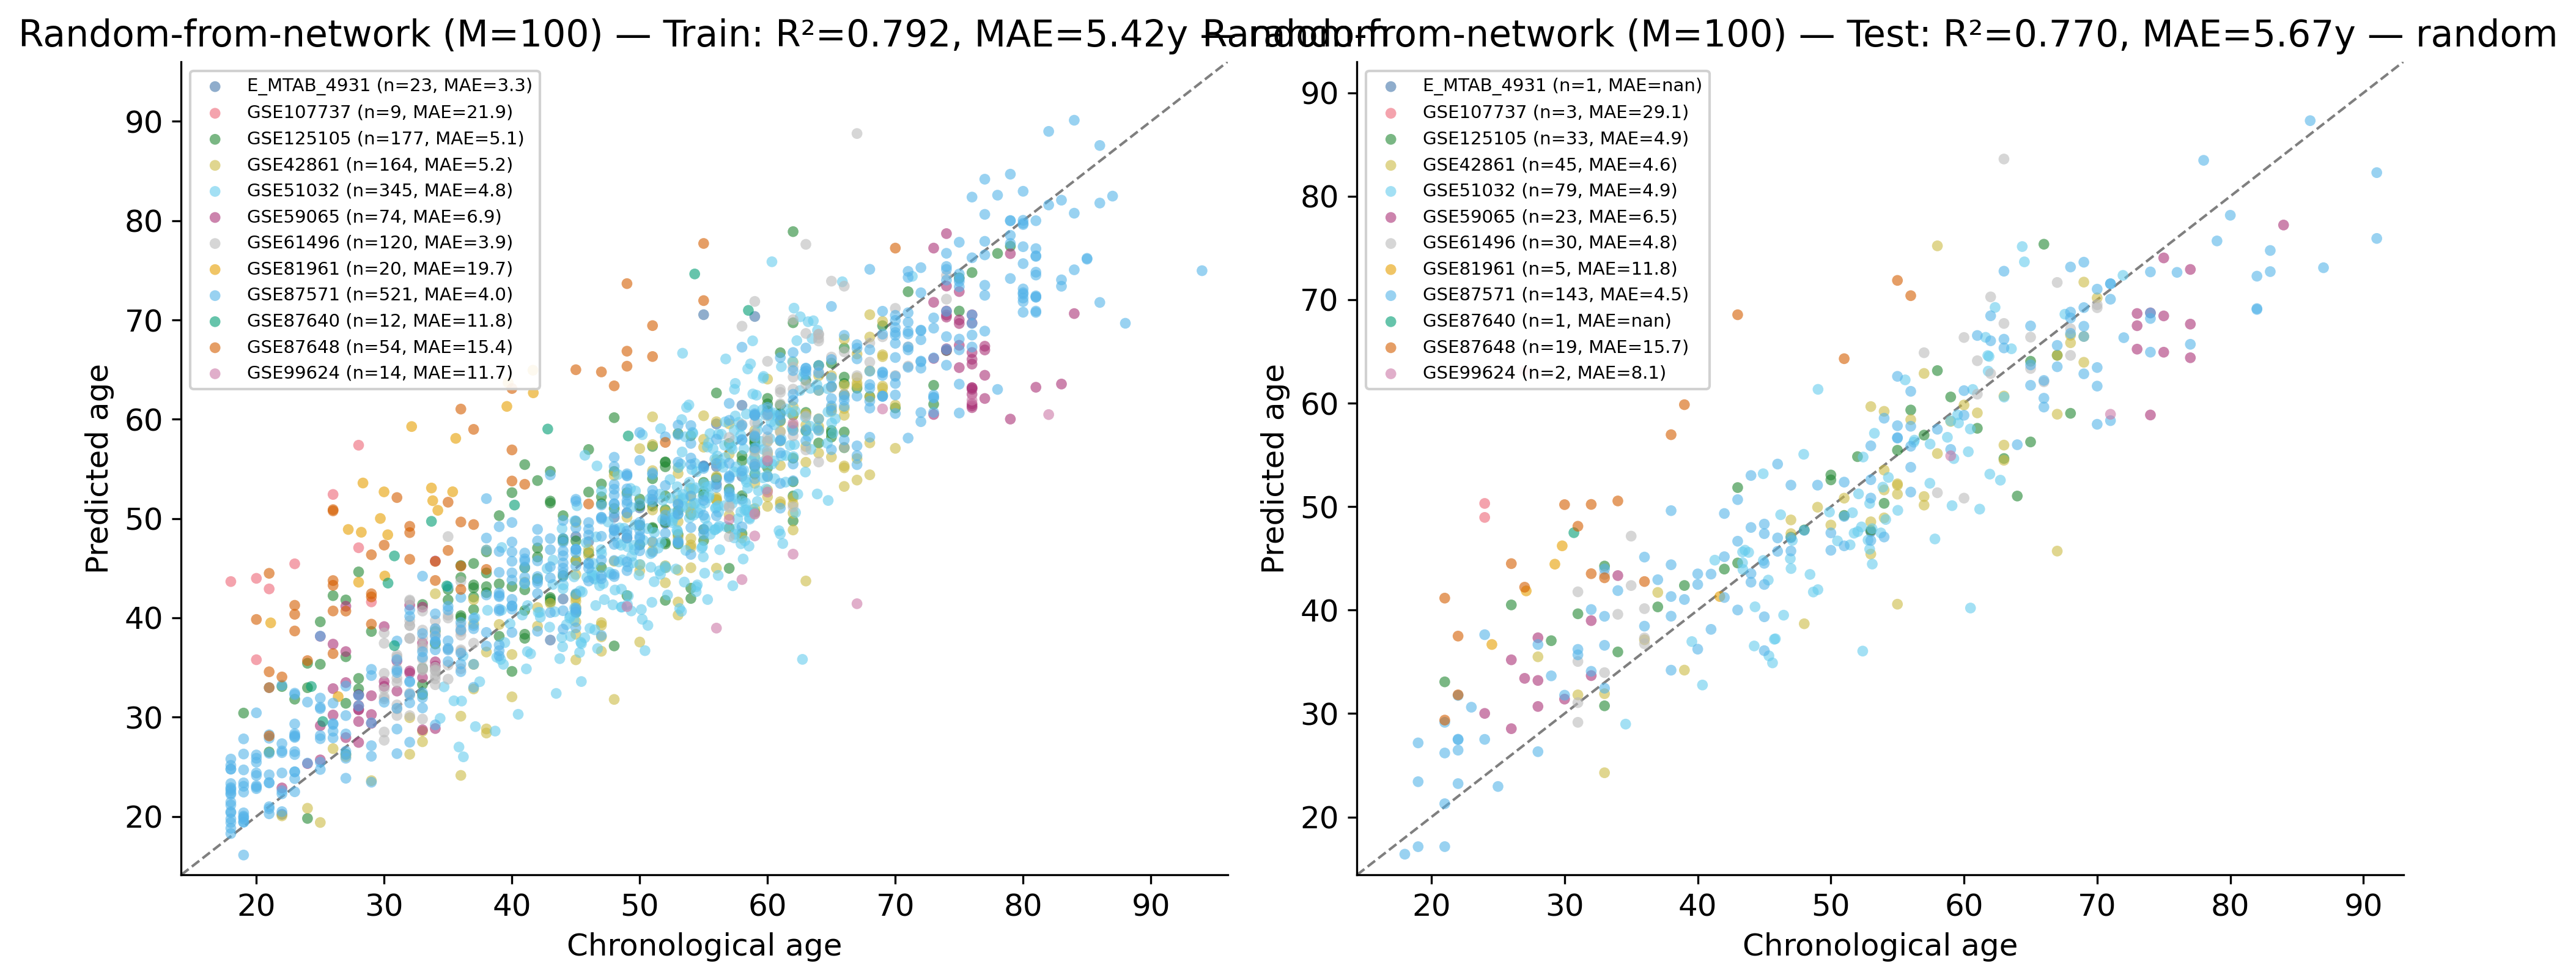

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_clock/random/scatter_rand_clust_M100.csv


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_clock/random/scatter_rand_clust_M100.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

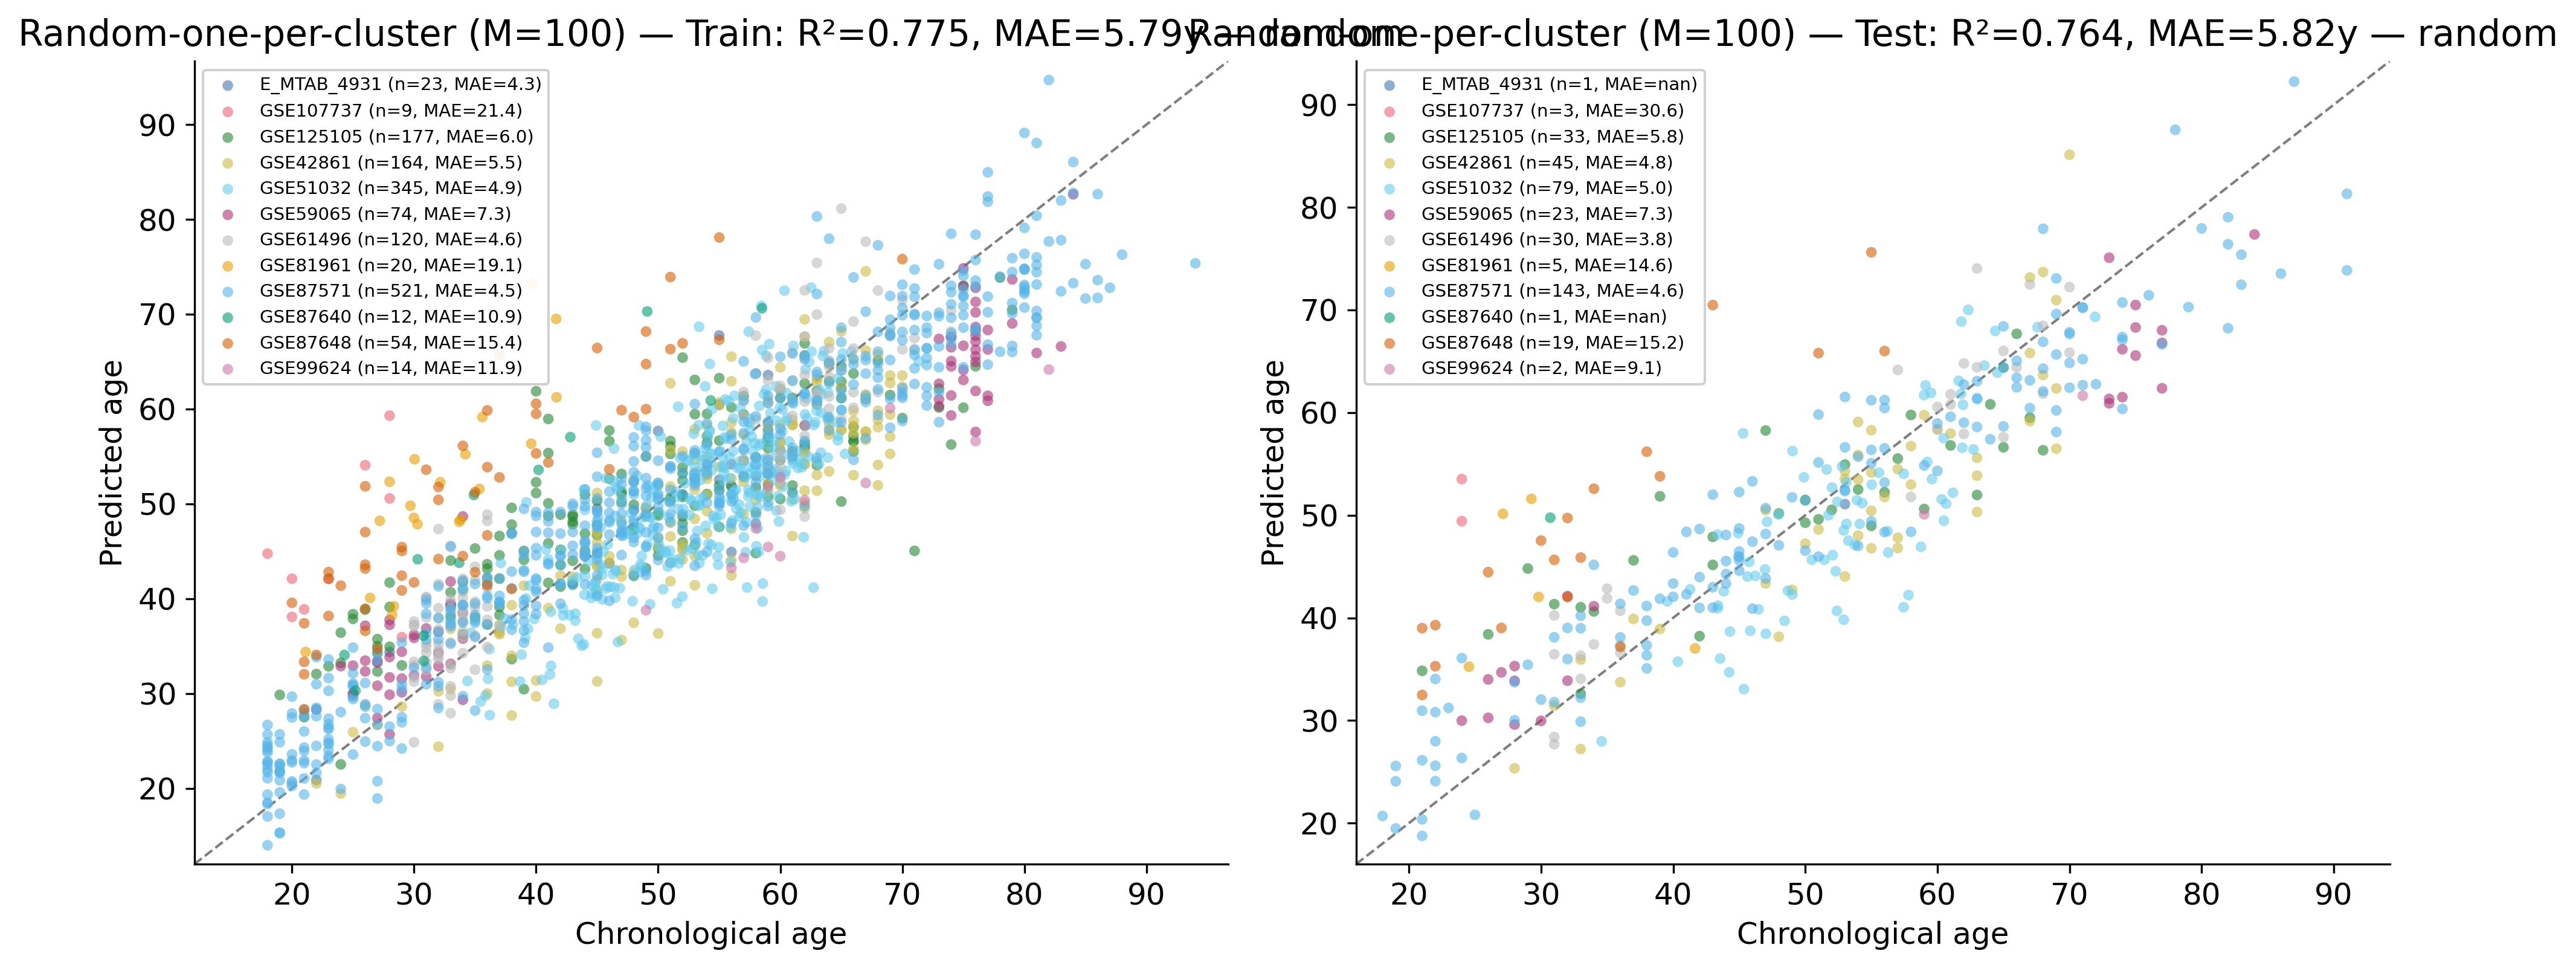

In [11]:
# ── Predicted-vs-actual scatter for random methods at M=100 ──
# Uses the saved random-from-network and random-one-per-cluster clocks at M=100,
# re-applies them to the training-mode split (train + test), and plots both side
# by side per method. Predictions are recomputed here because the saved clock
# pickles only store coefficients + scaler — not the per-sample predictions.

M_TARGET = 100

def _predict_with_saved_clock(clock, df_meth, indices):
    """Apply a saved clock dict (with cpgs, coefs, intercept, scaler_*) to a row subset."""
    cpgs = list(clock["cpgs"])
    avail = [c for c in cpgs if c in df_meth.columns]
    if len(avail) != len(cpgs):
        # Shouldn't happen for in-distribution data, but guard anyway
        print(f"    ⚠ {len(cpgs) - len(avail)} CpGs missing from df_meth — re-aligning")
    # Build X in the same order as saved
    X = df_meth.iloc[indices][cpgs].fillna(df_meth[cpgs].mean()).values
    sc_mean  = np.asarray(clock["scaler_mean"],  dtype=float)
    sc_scale = np.asarray(clock["scaler_scale"], dtype=float)
    coefs    = np.asarray(clock["coefs"],        dtype=float)
    intercept = float(clock["intercept"])
    X_s = (X - sc_mean) / np.where(sc_scale > 0, sc_scale, 1.0)
    return X_s @ coefs + intercept


for mode, res in all_mode_results.items():
    out_dir = res["out_dir"]
    i_tr, i_te = res["i_tr"], res["i_te"]
    title_suffix = f" — {mode.replace('_', ' ')}"
    sids = np.asarray(study_ids)

    methods = [
        ("Random-from-network",       res["rand_net_best_by_M"],   "rand_net"),
        ("Random-one-per-cluster",    res["rand_clust_best_by_M"], "rand_clust"),
    ]

    for label, clocks_by_M, fname_tag in methods:
        if M_TARGET not in clocks_by_M:
            print(f"  [{mode}] {label}: no saved clock at M={M_TARGET} — skipping")
            continue
        clock = clocks_by_M[M_TARGET]

        y_tr = ages[i_tr]; y_te = ages[i_te]
        p_tr = _predict_with_saved_clock(clock, df_meth, i_tr)
        p_te = _predict_with_saved_clock(clock, df_meth, i_te)
        s_tr = sids[i_tr]; s_te = sids[i_te]

        # Persist the per-sample data for the composite figure / future replots
        df_scatter = pd.concat([
            pd.DataFrame({"split": "train", "y_true": y_tr, "y_pred": p_tr, "study": s_tr}),
            pd.DataFrame({"split": "test",  "y_true": y_te, "y_pred": p_te, "study": s_te}),
        ], ignore_index=True)
        scatter_csv = out_dir / f"scatter_{fname_tag}_M{M_TARGET}.csv"
        df_scatter.to_csv(scatter_csv, index=False)
        print(f"  -> {scatter_csv}")

        fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
        for ax, split, y, pred, studies in [
            (axes[0], "Train", y_tr, p_tr, s_tr),
            (axes[1], "Test",  y_te, p_te, s_te),
        ]:
            lims = [min(y.min(), pred.min()) - 2, max(y.max(), pred.max()) + 2]
            ax.plot(lims, lims, "k--", lw=1, alpha=0.5, zorder=0)
            if studies is not None and len(set(studies)) > 1:
                for i, s in enumerate(sorted(set(studies))):
                    mask = np.array(studies) == s
                    mae_s = mean_absolute_error(y[mask], pred[mask]) if mask.sum() >= 2 else float("nan")
                    ax.scatter(y[mask], pred[mask], s=18, alpha=0.6,
                                color=STUDY_PALETTE[i % len(STUDY_PALETTE)],
                                edgecolors="none",
                                label=f"{s} (n={mask.sum()}, MAE={mae_s:.1f})", zorder=2)
                ax.legend(fontsize=7, loc="upper left", frameon=True,
                          facecolor="white", edgecolor="#CCC", framealpha=0.9)
            else:
                ax.scatter(y, pred, s=18, alpha=0.6, color="#332288", edgecolors="none")
            r2 = r2_score(y, pred); mae = mean_absolute_error(y, pred)
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_xlabel("Chronological age"); ax.set_ylabel("Predicted age")
            ax.set_title(f"{label} (M={M_TARGET}) — {split}: R²={r2:.3f}, MAE={mae:.2f}y{title_suffix}")
            sns.despine(ax=ax)

        fig.tight_layout()
        _save(fig, out_dir / f"scatter_{fname_tag}_M{M_TARGET}.png")
        plt.show()


## 8. Reference clocks: predicted-vs-actual on the test set (per mode)

In [12]:
for mode, res in all_mode_results.items():
    out_dir = res["out_dir"]
    ref_results = res["ref_results"]
    title_suffix = f" — {mode.replace('_', ' ')}"

    if not ref_results:
        print(f"  No reference clock results to plot for mode={mode}")
        continue

    # Skip when running from CSV cache — per-sample predictions aren't stored there
    if not any("y_test" in r for r in ref_results.values()):
        print(f"  [{mode}] Skipping reference-clock scatter — "
              f"loaded from CSV cache, no per-sample predictions available.")
        continue

    n = len(ref_results)
    ncols = min(3, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                              squeeze=False)

    for ax, (cn, r) in zip(axes.flatten(), ref_results.items()):
        y, pred, studies = r["y_test"], r["pred_test"], r.get("studies_test")
        lims = [min(y.min(), pred.min()) - 2, max(y.max(), pred.max()) + 2]
        ax.plot(lims, lims, "k--", lw=1, alpha=0.5, zorder=0)
        if studies is not None and len(set(studies)) > 1:
            for i, s in enumerate(sorted(set(studies))):
                mask = np.array(studies) == s
                ax.scatter(y[mask], pred[mask], s=18, alpha=0.6,
                            color=STUDY_PALETTE[i % len(STUDY_PALETTE)],
                            edgecolors="none")
        else:
            ax.scatter(y, pred, s=18, alpha=0.6, color="#666", edgecolors="none")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Chronological age"); ax.set_ylabel("Predicted age")
        ax.set_title(f"{r['clock_name']}: R²={r['r2_test']:.3f}, MAE={r['mae_test']:.2f}y")
        sns.despine(ax=ax)

    # Hide leftover axes
    for i in range(n, nrows * ncols):
        axes.flatten()[i].axis("off")

    fig.suptitle(f"Reference clocks (pyaging){title_suffix}", y=1.02)
    fig.tight_layout()
    _save(fig, out_dir / "reference_clocks_scatter.png")
    plt.show()

  [random] Skipping reference-clock scatter — loaded from CSV cache, no per-sample predictions available.


## 9. Bar chart: network clock vs reference clocks (per mode)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  -> outputs/05_clock/random/clock_comparison.png


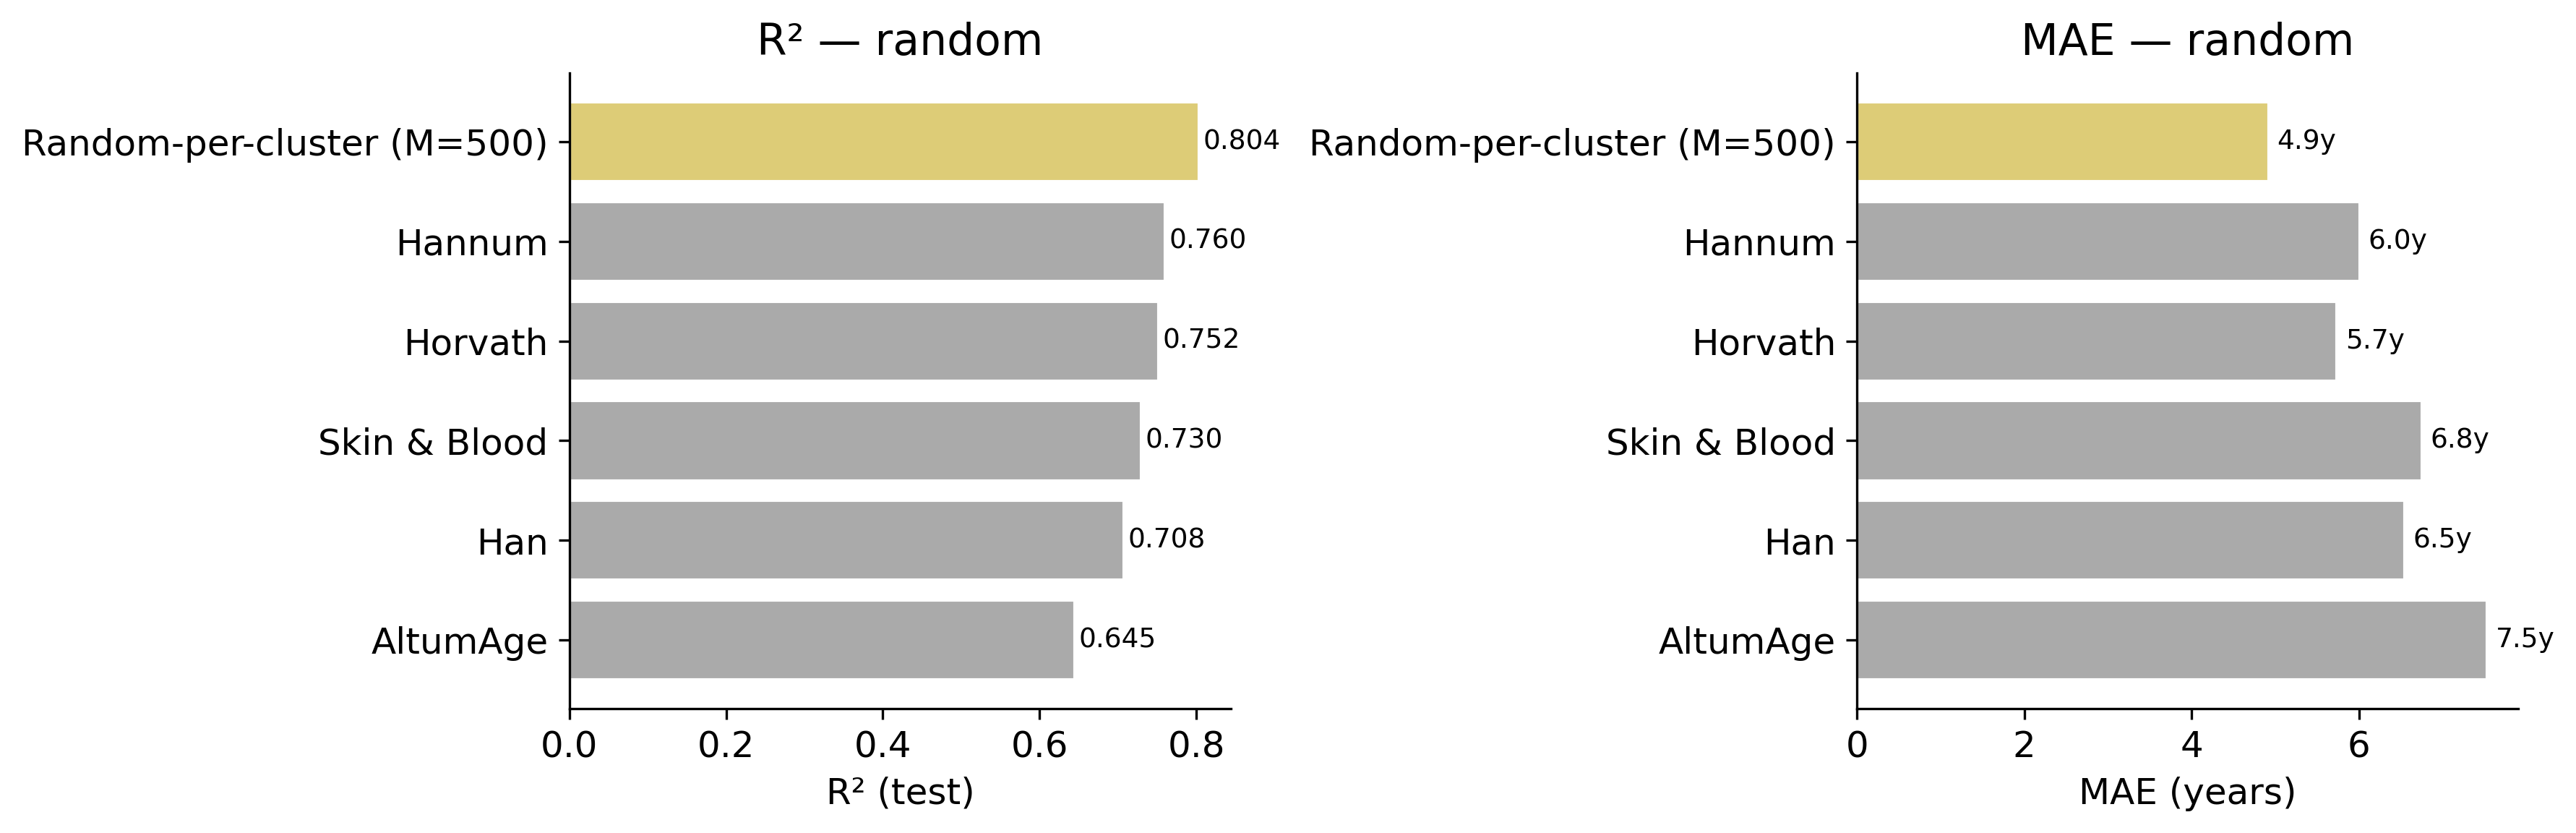

In [13]:
# Bar comparison: best random-one-per-cluster clock vs. reference clocks
for mode, res in all_mode_results.items():
    out_dir = res["out_dir"]
    ref_results = res["ref_results"]
    title_suffix = f" — {mode.replace('_', ' ')}"

    # Pick the best clock from random-one-per-cluster (highest R²)
    rand_clust_dict = res["rand_clust_best_by_M"]
    if not rand_clust_dict:
        print(f"[{mode}] No random-per-cluster clocks — skipping comparison plot")
        continue
    best_M, best_clock = max(rand_clust_dict.items(), key=lambda kv: kv[1]["r2_test"])

    rows = [{"Clock": f"Random-per-cluster (M={best_M})",
              "R2": best_clock["r2_test"], "MAE": best_clock["mae_test"],
              "n_CpGs": best_clock["n_cpgs_nonzero"]}]
    for cn, r in ref_results.items():
        rows.append({"Clock": r["clock_name"],
                      "R2": r["r2_test"], "MAE": r["mae_test"],
                      "n_CpGs": r.get("n_test_samples", -1)})
    df_cmp = pd.DataFrame(rows).sort_values("R2")
    df_cmp.to_csv(out_dir / "clock_comparison.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.5 * len(df_cmp))))
    colors = ["#DDCC77" if "Random" in c else "#AAAAAA" for c in df_cmp["Clock"]]
    axes[0].barh(df_cmp["Clock"], df_cmp["R2"], color=colors, edgecolor="white")
    axes[0].set_xlabel("R² (test)")
    axes[0].set_title(f"R²{title_suffix}")
    for i, (_, r) in enumerate(df_cmp.iterrows()):
        axes[0].text(r["R2"] + 0.005, i, f"{r['R2']:.3f}", va="center", fontsize=9)
    sns.despine(ax=axes[0])

    axes[1].barh(df_cmp["Clock"], df_cmp["MAE"], color=colors, edgecolor="white")
    axes[1].set_xlabel("MAE (years)")
    axes[1].set_title(f"MAE{title_suffix}")
    for i, (_, r) in enumerate(df_cmp.iterrows()):
        axes[1].text(r["MAE"] + 0.1, i, f"{r['MAE']:.1f}y", va="center", fontsize=9)
    sns.despine(ax=axes[1])
    fig.tight_layout()
    _save(fig, out_dir / "clock_comparison.png")
    plt.show()


## 10. Ensemble null distributions (per mode)

For the network clock at its best `n_modules`:
1. **Random rep / cluster** — keep the same modules, but pick a random CpG from each (instead of PageRank centrality)
2. **Random CpGs (global)** — pick `n_cpgs` totally random CpGs from the full filtered matrix

Tests whether (a) PageRank's central CpG choice matters, (b) the modular structure itself matters.

With `MAX_MODULES = 300` capped above, this finishes in reasonable time. Each ensemble does N_ENSEMBLE = 30 ElasticNet fits per category.

In [14]:
# (Disabled — the ensemble distributions are now generated by the main sweep loop
# above with N_REPS_SWEEP=30 reps per M for both random methods. See the saved
# random_sweep_results.csv and the R² vs M plot for the ensemble view.)
print("Legacy ensemble cell skipped (replaced by the main sweep loop).")


Legacy ensemble cell skipped (replaced by the main sweep loop).


## 11. Summary across modes

In [15]:
# Summary CSV — best random-per-cluster clock + reference clocks per mode
summary_rows = []
for mode, res in all_mode_results.items():
    rand_clust_dict = res["rand_clust_best_by_M"]
    if rand_clust_dict:
        best_M, best_clock = max(rand_clust_dict.items(),
                                    key=lambda kv: kv[1]["r2_test"])
        summary_rows.append({
            "mode": mode,
            "clock": f"Random-per-cluster ({best_M} mod)",
            "r2_test": best_clock["r2_test"],
            "mae_test": best_clock["mae_test"],
            "n_train": len(res["i_tr"]),
            "n_test": len(res["i_te"]),
        })
    # Also include the best random-from-network for completeness
    rand_net_dict = res["rand_net_best_by_M"]
    if rand_net_dict:
        best_M, best_clock = max(rand_net_dict.items(),
                                    key=lambda kv: kv[1]["r2_test"])
        summary_rows.append({
            "mode": mode,
            "clock": f"Random-from-network ({best_M} mod)",
            "r2_test": best_clock["r2_test"],
            "mae_test": best_clock["mae_test"],
            "n_train": len(res["i_tr"]),
            "n_test": len(res["i_te"]),
        })
    for cn, r in res["ref_results"].items():
        summary_rows.append({
            "mode": mode,
            "clock": r["clock_name"],
            "r2_test": r["r2_test"],
            "mae_test": r["mae_test"],
            "n_train": len(res["i_tr"]),
            "n_test": len(res["i_te"]),
        })

df_all = pd.DataFrame(summary_rows)
df_all.to_csv("outputs/05_clock/all_modes_summary.csv", index=False)
print(df_all.to_string(index=False))


  mode                         clock  r2_test  mae_test  n_train  n_test
random  Random-per-cluster (500 mod) 0.803895  4.920252     1533     384
random Random-from-network (400 mod) 0.806182  5.021562     1533     384
random                       Horvath 0.751907  5.738319     1533     384
random                        Hannum 0.760198  6.010935     1533     384
random                      AltumAge 0.644747  7.530631     1533     384
random                  Skin & Blood 0.730167  6.750061     1533     384
random                           Han 0.707591  6.545606     1533     384
